# Pytorch Computer Vision


1. 准备开发环境

In [29]:
import torch
import torch.nn as nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.4.1+cu121
0.19.1+cu121


2. 准备数据集
   1. 使用MNIST数据集，Fashion-MNIST数据集
transform = transforms.ToTensor() 表示将图像转换为张量。
target_transform = None 表示不进行标签转换。

In [30]:
train_data = datasets.FashionMNIST(root = "data",
                                   train =True,
                                   download = True,
                                   transform = transforms.ToTensor(),
                                   target_transform = None
                                   )

test_data = datasets.FashionMNIST(root = "data",
                                   download = True,
                                   train=False,
                                   transform = transforms.ToTensor(),
                                   target_transform = None
                                   )

In [31]:
len(train_data), len(test_data)

(60000, 10000)

In [32]:
image , label = train_data[0]

class_names = train_data.classes
print(class_names)
class_idx = train_data.class_to_idx
print(class_idx)

print(f"image shape {image.shape}, label  {label}")

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
image shape torch.Size([1, 28, 28]), label  9


3. 可视化数据  
在 PyTorch 里，squeeze 是一个张量操作函数，其用途是去除维度大小为 1 的维度

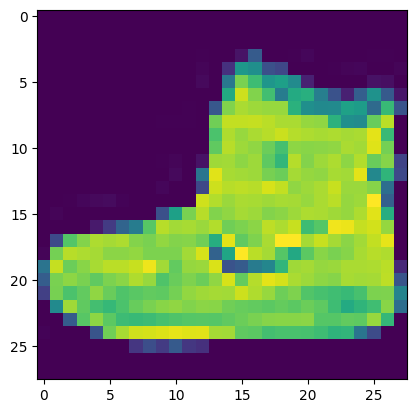

In [33]:
plt.imshow(image.squeeze())

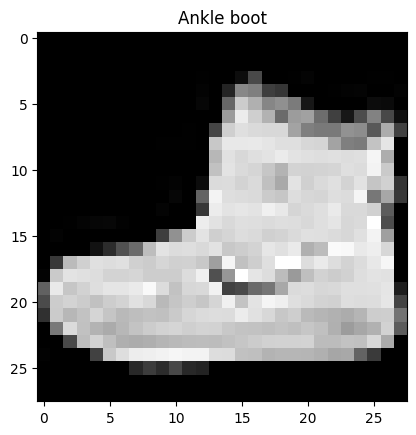

In [34]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

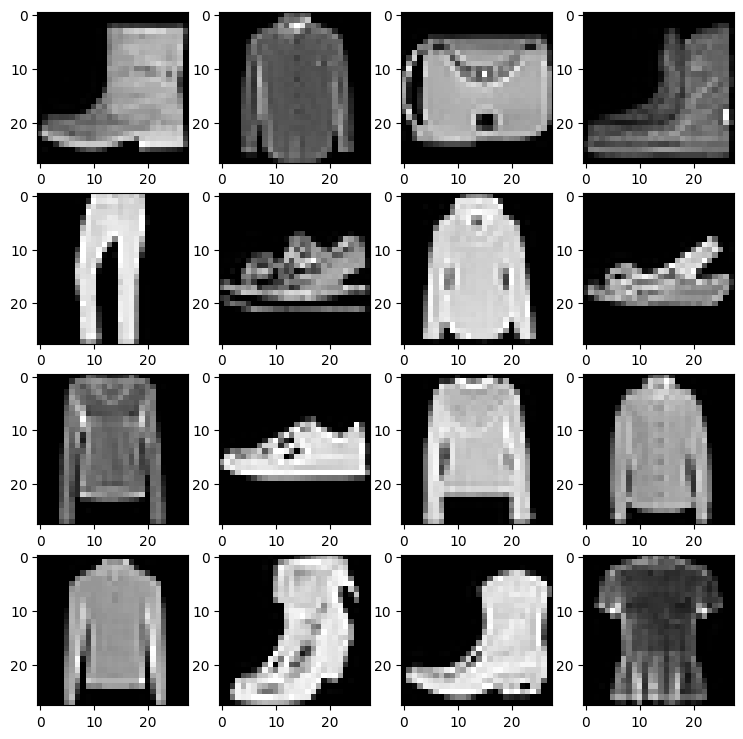

In [35]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
row,col = 4,4
for i in range(1,row*col+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img,label = train_data[random_idx]
  fig.add_subplot(row,col,i)
  plt.imshow(img.squeeze(),cmap="gray")

In [36]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

train_dataloader, test_dataloader

32

32 32


Text(0.5, 1.0, 'Pullover')

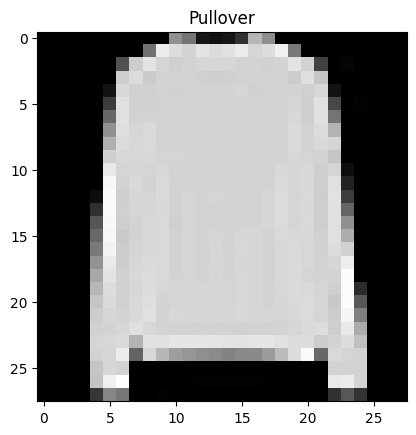

In [63]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(len(train_features_batch), len(train_labels_batch))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])

4. 创建一个模型

In [46]:
flatten_model = nn.Flatten

x  = train_features_batch[0]
print(x.shape)

output = flatten_model(x)


torch.Size([1, 28, 28])


In [ ]:
class ModelFashionMNIST(nn.Module):
    def __init__(self, 
                 input_shape: int, 
                 hidden_units: int, 
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            #nn.Linear 层实现的是一个线性变换，只会对输入数据的最后一维进行变换。
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [57]:
model_0 = ModelFashionMNIST(
    input_shape=28*28,#28*28
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")

model_0

ModelFashionMNIST(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [58]:
x = torch.rand(1,1,28 ,28)
model_0_output = model_0(x)
model_0_output.shape

torch.Size([1, 10])

In [59]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0041, -0.0278, -0.0298,  ...,  0.0026,  0.0164,  0.0123],
                      [ 0.0244,  0.0047, -0.0286,  ..., -0.0071,  0.0120,  0.0086],
                      [ 0.0105, -0.0087, -0.0262,  ..., -0.0273, -0.0189, -0.0060],
                      ...,
                      [-0.0249, -0.0350,  0.0157,  ...,  0.0151,  0.0039, -0.0171],
                      [ 0.0053,  0.0281,  0.0291,  ..., -0.0330, -0.0036,  0.0018],
                      [ 0.0173,  0.0136,  0.0343,  ..., -0.0125,  0.0241, -0.0111]])),
             ('layer_stack.1.bias',
              tensor([ 0.0299, -0.0255,  0.0271,  0.0354, -0.0307,  0.0291,  0.0098,  0.0174,
                      -0.0110,  0.0256])),
             ('layer_stack.2.weight',
              tensor([[ 0.0705, -0.2330,  0.2761,  0.0014, -0.0759,  0.0810,  0.0382, -0.2899,
                        0.3126, -0.0341],
                      [ 0.0924, -0.0585, -0.2933, -0.2708, -0.0910, -0.1011,  0.

5. 设置损失函数，优化器

In [69]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

6. 训练模型

In [71]:
from tqdm.auto import tqdm


epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_loss = 0
  #PyTorch 模型支持批量处理数据，能够自动对输入的每个样本独立执行相同的操作。
  # 所以，即便模型设计为接收单个样本的输入，它也能处理包含多个样本的批量输入。
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
  train_loss /= len(train_dataloader)
  print(f"Train loss: {train_loss:4f}")
  
  
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:
      test_pred = model_0(X)
      test_loss  += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
  print(f"Test loss: {test_loss:4f} \nTest acc: {test_acc:4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.381807
Test loss: 0.448509 
Test acc: 26359.375000
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.380687
Test loss: 0.445927 
Test acc: 26396.875000
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.378582
Test loss: 0.450409 
Test acc: 26384.375000
